In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
from google.colab import files
uploaded = files.upload()

Saving BlinkIT Grocery Data.xlsx to BlinkIT Grocery Data.xlsx


***SAMPLE DATA***


In [25]:
df = pd.read_csv("BlinkIT Grocery Data.csv")
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Total Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


### **Size of data**


In [12]:
print("Size of Data",df.shape)

Size of Data (8523, 12)


### **field info**


In [13]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Total Sales', 'Rating'],
      dtype='object')


**Data Types**

In [14]:
df.dtypes

,0
Item Fat Content,object
Item Identifier,object
Item Type,object
Outlet Establishment Year,int64
Outlet Identifier,object
Outlet Location Type,object
Outlet Size,object
Outlet Type,object
Item Visibility,float64
Item Weight,float64


**Data Cleaning**

In [10]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat' 'low fat' 'LF' 'reg']


In [12]:
df['Item Fat Content']= df['Item Fat Content'].replace({
    'low fat':'Low Fat',
    'LF':'Law Fat',
    'rg':'Regular'
})

In [13]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat' 'Law Fat' 'reg']


**Business Requirements**

**KPTs Requirements**


In [19]:
#Total Sales
Total_sales = df['Total Sales'].sum()
# Average sales
Average_sales = df['Total Sales'].mean()
# No of items
No_of_ItemsSold =df['Total Sales'].count()
#Average Rating
Average_rating = df['Rating'].mean()

#Display result
print(f"Total Sales: ${Total_sales:,.0f}")
print(f"Average Sales: ${Average_sales:,.0f}")
print(f"No od Item sold: {No_of_ItemsSold:,.0f}")
print(f"Average rating: {Average_rating:,.0f}")


Total Sales: $1,201,681
Average Sales: $141
No od Item sold: 8,523
Average rating: 4


**Chart Requirements**

**Total sales by Item**

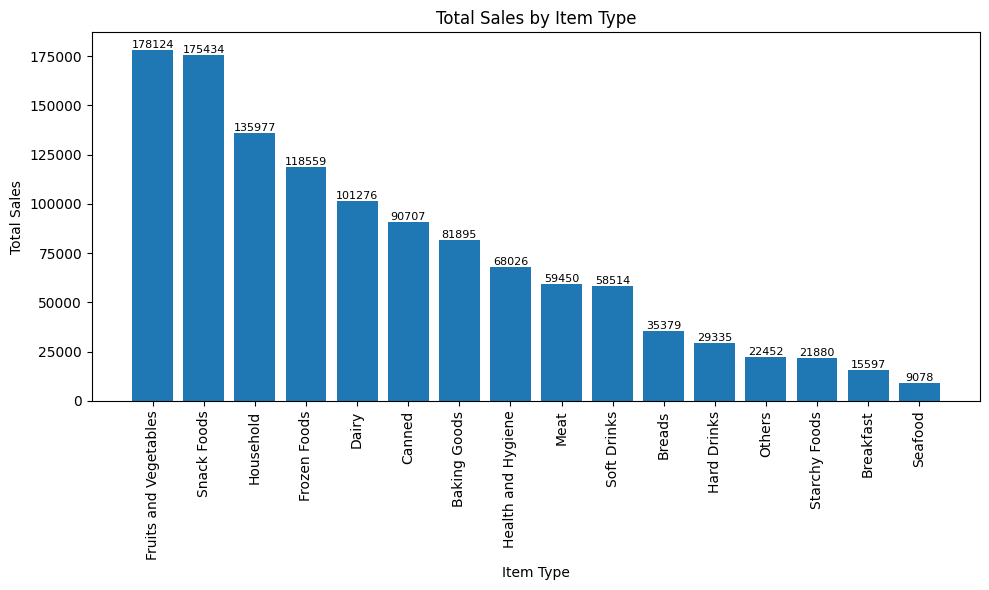

In [26]:
sales_by_type = df.groupby('Item Type')['Total Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(sales_by_type.index, sales_by_type.values)

plt.xticks(rotation=90)
plt.xlabel('Item Type')
plt.ylabel('Total Sales')
plt.title('Total Sales by Item Type')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():.0f}',
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.show()

**Fat content by outlet for total sales**

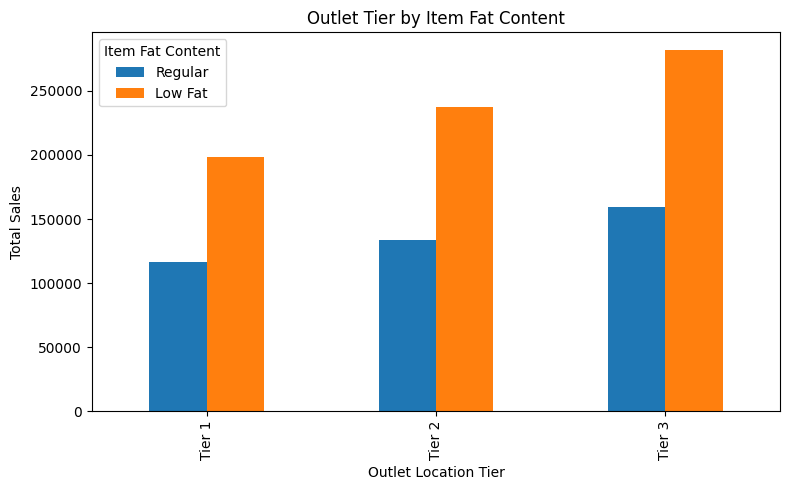

In [30]:
import matplotlib.pyplot as plt

grouped = df.groupby(['Outlet Location Type', 'Item Fat Content'])['Total Sales'].sum().unstack()

grouped = grouped[['Regular', 'Low Fat']]

ax = grouped.plot(
    kind='bar',
    figsize=(8, 5),
    title='Outlet Tier by Item Fat Content'
)

plt.xlabel('Outlet Location Tier')
plt.ylabel('Total Sales')
plt.legend(title='Item Fat Content')

plt.tight_layout()
plt.show()

**Total sales by outlet establishment**

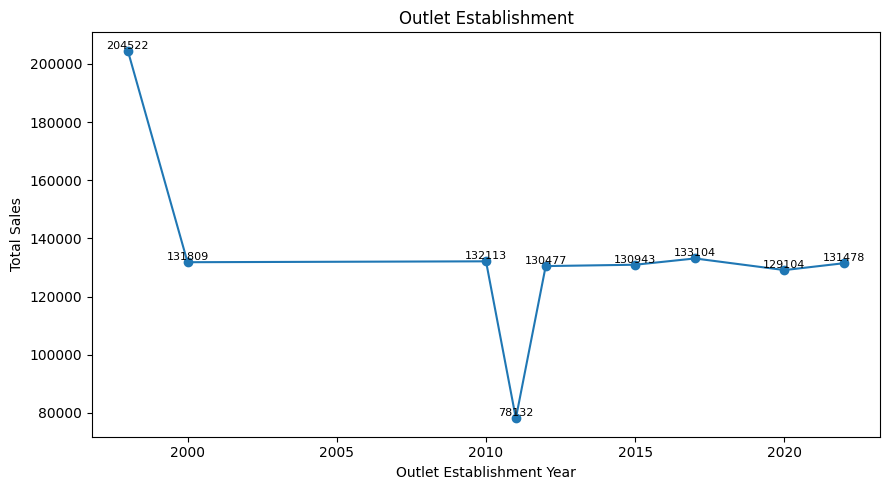

In [32]:
sales_by_year = df.groupby('Outlet Establishment Year')['Total Sales'].sum().sort_index()

plt.figure(figsize=(9, 5))

plt.plot(
    sales_by_year.index,
    sales_by_year.values,
    marker='o',
    linestyle='-'
)

plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
plt.title('Outlet Establishment')

for x, y in zip(sales_by_year.index, sales_by_year.values):
    plt.text(
        x,
        y,
        f'{y:.0f}',
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.show()

**Sales by Outlet size**

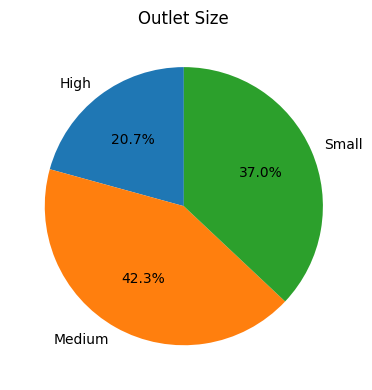

In [34]:
sales_by_size = df.groupby('Outlet Size')['Total Sales'].sum()

plt.figure(figsize=(4, 4))

plt.pie(
    sales_by_size,
    labels=sales_by_size.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Outlet Size')
plt.tight_layout()
plt.show()

**Sales by outlet location**

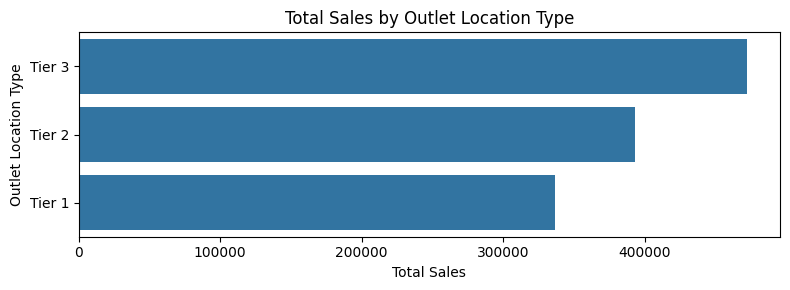

In [39]:
sales_by_location = df.groupby('Outlet Location Type')['Total Sales'].sum().reset_index()

sales_by_location = sales_by_location.sort_values(
    'Total Sales',
    ascending=False
)

plt.figure(figsize=(8, 3))  # Smaller height, enough width

ax = sns.barplot(
    x='Total Sales',
    y='Outlet Location Type',
    data=sales_by_location
)

plt.title('Total Sales by Outlet Location Type')
plt.xlabel('Total Sales')
plt.ylabel('Outlet Location Type')

plt.tight_layout()  # Ensures layout fits without scroll
plt.show()